# Предсказание цен на жилье с использованием модели линейной регрессии

- Датасет: https://www.kaggle.com/competitions/two-sigma-connect-rental-listing-inquiries/overview

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import math
import re
import zipfile, os
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
!gdown 1T5lTGqpn4kyMzTTSgI0SHG-PI0aYceV9 # train.json.zip
!gdown 1bn6y3916RIAxplOd1yuabXqhYT2Hz6xZ # test.json.zip
!gdown 1YaCHM5-zflQ3H8FmtDEy0TE0NZLFsuQp # submission.csv.zip
!gdown 1WEpOWcrDHN_inVfLxJiMxLMO6nOZrmma # images_sample.zip

Downloading...
From: https://drive.google.com/uc?id=1T5lTGqpn4kyMzTTSgI0SHG-PI0aYceV9
To: /content/train.json.zip
100% 21.0M/21.0M [00:00<00:00, 214MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1bn6y3916RIAxplOd1yuabXqhYT2Hz6xZ
From (redirected): https://drive.google.com/uc?id=1bn6y3916RIAxplOd1yuabXqhYT2Hz6xZ&confirm=t&uuid=483a76b6-8b70-4789-85c7-4d796b266143
To: /content/test.json.zip
100% 31.5M/31.5M [00:00<00:00, 58.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YaCHM5-zflQ3H8FmtDEy0TE0NZLFsuQp
To: /content/sample_submission.csv.zip
100% 306k/306k [00:00<00:00, 79.2MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1WEpOWcrDHN_inVfLxJiMxLMO6nOZrmma
From (redirected): https://drive.google.com/uc?id=1WEpOWcrDHN_inVfLxJiMxLMO6nOZrmma&confirm=t&uuid=c8dadaac-a682-45c9-be1c-2682c3809fe8
To: /content/images_sample.zip
100% 58.0M/58.0M [00:00<00:00, 83.6MB/s]


In [3]:
zip_files = ["/content/train.json.zip",
             "/content/test.json.zip",
             "/content/sample_submission.csv.zip",
             "/content/images_sample.zip" # выборка из 100 изображений по listing_id
             ]

for zip_path in zip_files:
  with zipfile.ZipFile(zip_path, 'r') as zip_file:
    zip_file.extractall("/content/")
  os.remove(zip_path)

## 2. Exploratory Data Analysis

In [4]:
train_data = pd.read_json("/content/train.json")
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [5]:
train_data[:3]

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium


В описании соревнования предлагается задача мултиклассовой классификации (таргет - "interest_level"), однако в целях обучения рассмотрим задачу регрессии (таргет - "price", предсказание цены квартиры).
- Числовые признаки: bathrooms, bedrooms, latitude, longitude;
- Категориальные признаки: created, display_address, features, street_address, interest_level;
- ID: building_id, manager_id, listing_id;
- Есть изображения - photos (не везде);
- Таргет - price.

In [6]:
train_data.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

In [7]:
# подправим типы данных
train_data['listing_id'] = train_data['listing_id'].astype('str')
train_data['bathrooms'] = train_data['bathrooms'].astype('int')

In [8]:
# убираем: display_address, street_address (позже кластеризуем по широте и долготе)
# убираем: building_id, manager_id, created
# photos, listing_id (пока что, возможно в дальнейшем используем также фото)
# description частично повторяет features (пока удалим, потом мб почистим и превратим в эмбеддинг или представление tfidf)

columns_to_drop = ['display_address', 'street_address', 'building_id',
                     'created', 'listing_id','manager_id', 'photos','description']

def delete_cols(data, columns_to_drop):
  result_df = data.copy()
  for col in columns_to_drop:
    if col in result_df.columns:
     result_df.drop(col, axis=1, inplace=True)

  return result_df

In [9]:
train_data = delete_cols(train_data, columns_to_drop)
train_data

,bathrooms,bedrooms,features,latitude,longitude,price,interest_level
4,1,1,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,-73.9539,2400,medium
6,1,2,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,-73.9722,3800,low
9,1,2,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,-73.9625,3495,medium
10,1,3,[],40.7145,-73.9425,3000,medium
15,1,0,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,-73.9743,2795,low
...,...,...,...,...,...,...,...
124000,1,3,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,-73.9396,2800,low
124002,1,2,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,-73.9578,2395,medium
124004,1,1,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,-73.9554,1850,medium
124008,1,2,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,-74.0017,4195,medium


In [10]:
# почистим от выбросов по цене
def cleaner(data, column_name:str) -> pd.DataFrame:
  q1 = data[column_name].quantile(q=0.01)
  q2 = data[column_name].quantile(q=0.99)
  cleaned_data = data[(data[column_name] > q1) & (data[column_name] < q2)].reset_index(drop=True)
  return cleaned_data

In [11]:
train_cleaned = cleaner(train_data, "price")

In [12]:
train_cleaned.describe()

,bathrooms,bedrooms,latitude,longitude,price
count,48343.000000,48343.000000,48343.000000,48343.000000,48343.000000
mean,1.185259,1.534204,40.741655,-73.957080,3535.167222
std,0.447501,1.101291,0.617355,1.138152,1585.625499
min,0.000000,0.000000,0.000000,-118.271000,1485.000000
25%,1.000000,1.000000,40.728300,-73.991800,2500.000000
50%,1.000000,1.000000,40.751600,-73.978100,3150.000000
75%,1.000000,2.000000,40.773900,-73.955200,4062.000000
max,10.000000,8.000000,43.034600,0.000000,12995.000000


In [13]:
# в спальнях и ваннах тоже есть какие-то значения выбросы
out_row = train_cleaned[(train_cleaned["bathrooms"] == 10) | (train_cleaned["bedrooms"] == 8)]
display(out_row)

# значение 10 ванн - скорее всего опечатка (должно быть 1 за такую-то цену)
train_cleaned.loc[train_cleaned["bathrooms"] == 10, "bathrooms"] = 1
if (train_cleaned.loc[(train_cleaned["bathrooms"] == 10)]).empty:
  print("Значение заменено")

,bathrooms,bedrooms,features,latitude,longitude,price,interest_level
4344,4,8,"[Hardwood Floors, No Fee, Dogs Allowed, Cats A...",40.6881,-73.9553,6500,low
11149,3,8,"[Roof Deck, Pre-War, Cats Allowed]",40.6764,-73.9767,9995,low
40719,10,2,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7633,-73.9849,3600,low


Значение заменено


In [14]:
train_cleaned.isna().sum() # NaN отсутствуют

,0
bathrooms,0
bedrooms,0
features,0
latitude,0
longitude,0
price,0
interest_level,0


## Target analysis

<Axes: xlabel='price', ylabel='Count'>

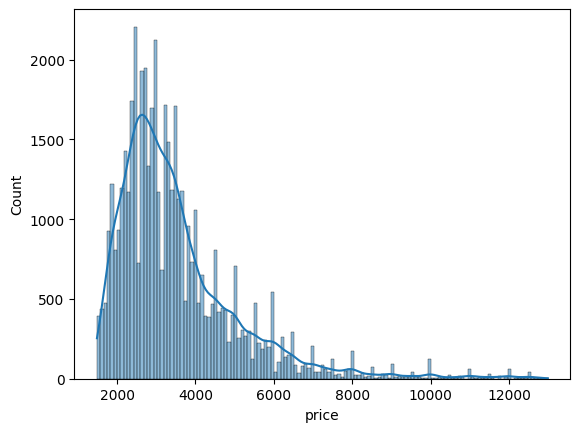

In [15]:
sns.histplot(data=train_cleaned["price"], kde=True)

- Right-skewed распределение - можно попытаться трансформировать в нормальное.

<Axes: xlabel='price'>

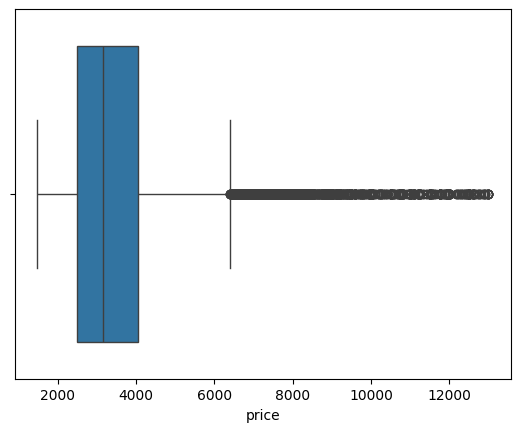

In [16]:
sns.boxplot(data=train_cleaned["price"], orient="h")

<Axes: ylabel='Count'>

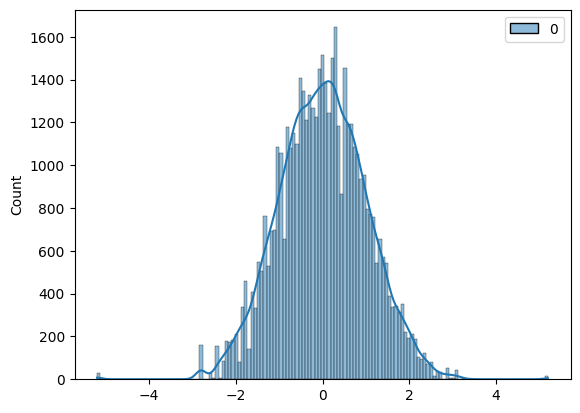

In [17]:
from sklearn.preprocessing import QuantileTransformer

qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal', random_state=42)
y = np.array(train_cleaned["price"].copy()).reshape(-1,1)
transformed_y = qt.fit_transform(y)
sns.histplot(data=transformed_y, kde=True)

- распределение таргета стало "нормальнее"

<Axes: >

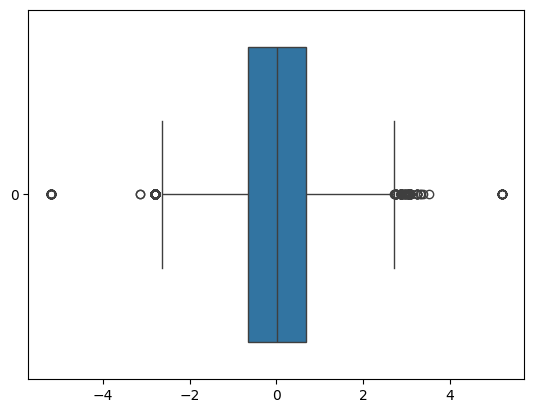

In [18]:
sns.boxplot(data=transformed_y, orient="h")

## Characteristics Analysis

In [19]:
# interest_level - перекодируем one-hot
train_cleaned["interest_level"].unique()

array(['medium', 'low', 'high'], dtype=object)

In [20]:
interest_mapping = {
    "low": 0,
    "medium": 1,
    "high": 2
}

train_cleaned["interest_level"] = train_cleaned["interest_level"].map(interest_mapping)
train_cleaned["interest_level"].unique()

array([1, 0, 2])

<Axes: xlabel='bathrooms', ylabel='Count'>

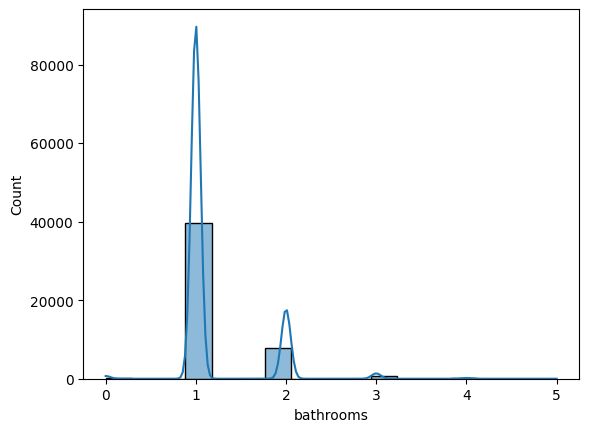

In [21]:
# bedrooms, bathrooms - выбросы убрали выше
sns.histplot(data=train_cleaned["bathrooms"], kde=True)

<Axes: xlabel='bedrooms', ylabel='Count'>

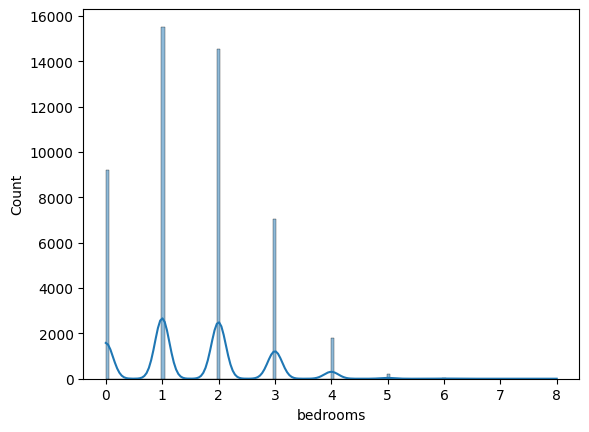

In [22]:
sns.histplot(data=train_cleaned["bedrooms"], kde=True)

## Complex analysis

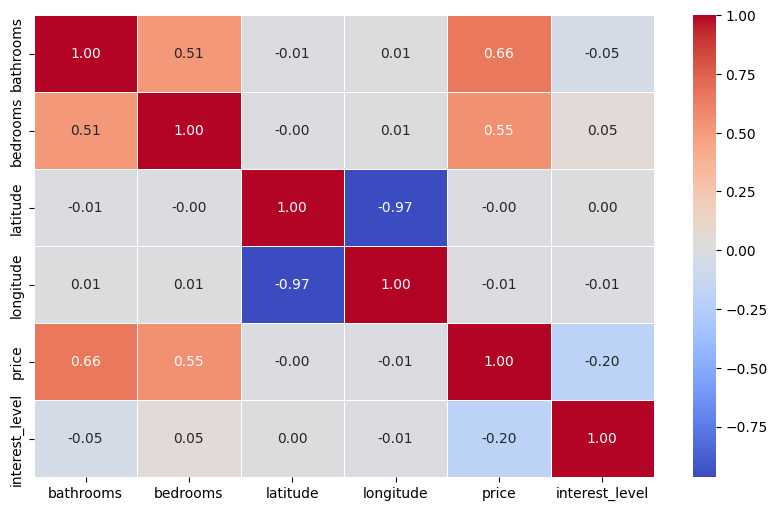

In [23]:
matrix = train_cleaned.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

- сильная обратная зависимость широты и долготы (-0.97) - заменим на cluster_label позднее
- сильная прямая зависимость цены и кол-ва ванн (0.66) и спален (0.55)
- слабая обратная зависимость цены от уровня интереса (- 0.20)

# 4. Creating features

In [24]:
creative_df = train_cleaned.copy()

In [25]:
creative_df['bathrooms_bedrooms'] = creative_df['bathrooms'] * creative_df['bedrooms']
creative_df['bathrooms_more_2'] = (creative_df['bathrooms'] >= 2).astype(int)
creative_df['bedrooms_more_2'] = (creative_df['bedrooms'] >= 2).astype(int)

In [26]:
# координаты центра манхэттена
center_lat, center_lon = 40.7128, -74.0060
creative_df['dist_to_center'] = np.sqrt((creative_df['latitude'] - center_lat)**2 + (creative_df['longitude'] - center_lon)**2)
creative_df['dist_log'] = np.log(creative_df['dist_to_center']  + 1)

In [27]:
creative_df[:3]

,bathrooms,bedrooms,features,latitude,longitude,price,interest_level,bathrooms_bedrooms,bathrooms_more_2,bedrooms_more_2,dist_to_center,dist_log
0,1,1,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,-73.9539,2400,1,1,0,0,0.052138,0.050825
1,1,2,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,-73.9722,3800,0,2,0,1,0.051232,0.049963
2,1,2,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,-73.9625,3495,1,2,0,1,0.062373,0.060505


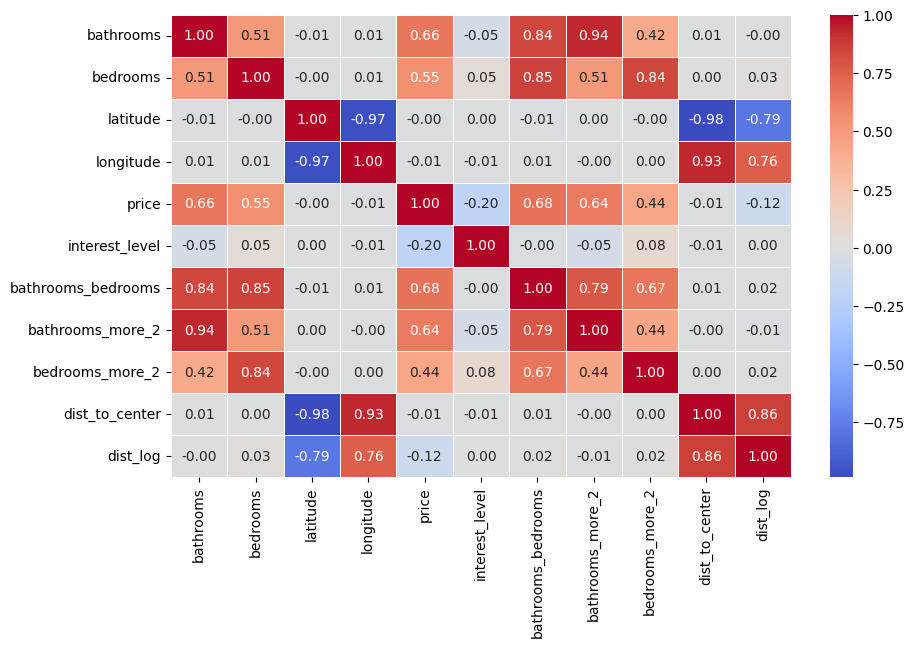

In [28]:
matrix = creative_df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

- созданные признаки ('bathrooms_bedrooms', 'bathrooms_more_2', 'bedrooms_more_2', 'dist_log') - есть корреляция с таргетом, оставляем;
'dist_to_center' - убираем.

In [29]:
creative_df = delete_cols(creative_df, columns_to_drop=['dist_to_center'])
creative_df[:3]

,bathrooms,bedrooms,features,latitude,longitude,price,interest_level,bathrooms_bedrooms,bathrooms_more_2,bedrooms_more_2,dist_log
0,1,1,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,-73.9539,2400,1,1,0,0,0.050825
1,1,2,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,-73.9722,3800,0,2,0,1,0.049963
2,1,2,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,-73.9625,3495,1,2,0,1,0.060505


In [30]:
# подправим типы данных
creative_df['bathrooms_more_2'] = creative_df['bathrooms_more_2'].astype('category')
creative_df['bedrooms_more_2'] = creative_df['bedrooms_more_2'].astype('category')
creative_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48343 entries, 0 to 48342
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   bathrooms           48343 non-null  int64   
 1   bedrooms            48343 non-null  int64   
 2   features            48343 non-null  object  
 3   latitude            48343 non-null  float64 
 4   longitude           48343 non-null  float64 
 5   price               48343 non-null  int64   
 6   interest_level      48343 non-null  int64   
 7   bathrooms_bedrooms  48343 non-null  int64   
 8   bathrooms_more_2    48343 non-null  category
 9   bedrooms_more_2     48343 non-null  category
 10  dist_log            48343 non-null  float64 
dtypes: category(2), float64(3), int64(5), object(1)
memory usage: 3.4+ MB


# 5. Get features from "features" column

In [31]:
def get_info_features(data):
  feature_data = data["features"]
  pattern = re.compile(r'[ \]\[\'\"]+') # очистка от пробелов, кв скобок, кавычек

  all_features = []
  unique_features = []
  data_with_features = data.copy()

  for idx, row in feature_data.items():
    row = str(row).lower()
    cleaned_features = pattern.sub('', row)
    idx_feats = set(cleaned_features.split(","))
    all_features.extend(idx_feats)

  unique_features = set(all_features)
  return all_features, unique_features

In [32]:
all_features, unique_features = get_info_features(train_cleaned)

In [33]:
from collections import Counter
cnt = Counter()
for f in all_features:
  if f != '':
    cnt[f] +=1
top20 = cnt.most_common(20)
top20 = dict(top20)
top20

{'elevator': 25718,
 'hardwoodfloors': 23177,
 'catsallowed': 23135,
 'dogsallowed': 21652,
 'doorman': 20547,
 'dishwasher': 20460,
 'laundryinbuilding': 18350,
 'nofee': 17796,
 'fitnesscenter': 12989,
 'laundryinunit': 9036,
 'pre-war': 8972,
 'roofdeck': 6482,
 'outdoorspace': 5134,
 'diningroom': 4904,
 'highspeedinternet': 4223,
 'balcony': 2963,
 'swimmingpool': 2643,
 'newconstruction': 2551,
 'terrace': 2207,
 'exclusive': 2075}

In [34]:
def features_encoder(data, top20:dict):
  creative_df = data.copy()

  # 0 по умолчанию
  for feature_name in top20.keys():
      creative_df[feature_name] = 0

  pattern = re.compile(r'[ \]\[\'\"]+')
  for idx, raw_features_list in creative_df['features'].items():
    features_as_string = str(raw_features_list).lower()
    cleaned_concatenated_features = pattern.sub('', features_as_string)
    individual_features = [f.strip() for f in cleaned_concatenated_features.split(',') if f.strip()]

    # для каждой фичи проставляем индентификатор 0/1
    for feature_token in individual_features:
        if feature_token in top20.keys():
            creative_df.loc[idx, feature_token] = 1
  return creative_df

In [35]:
creative_df["features"].iloc[0]

['Dining Room',
 'Pre-War',
 'Laundry in Building',
 'Dishwasher',
 'Hardwood Floors',
 'Dogs Allowed',
 'Cats Allowed']

In [36]:
creative_df = features_encoder(creative_df, top20)

In [37]:
assert creative_df["diningroom"].iloc[0] == 1, "Wrong"
assert creative_df["pre-war"].iloc[0] == 1, "Wrong"
assert creative_df["laundryinbuilding"].iloc[0] == 1, "Wrong"
assert creative_df["dishwasher"].iloc[0] == 1, "Wrong"
assert creative_df["hardwoodfloors"].iloc[0] == 1, "Wrong"
assert creative_df["dogsallowed"].iloc[0] == 1, "Wrong"
assert creative_df["catsallowed"].iloc[0] == 1, "Wrong"
print("Всё assert-ы прошли")

Всё assert-ы прошли


In [38]:
creative_df[:3]

,bathrooms,bedrooms,features,latitude,longitude,price,interest_level,bathrooms_bedrooms,bathrooms_more_2,bedrooms_more_2,...,pre-war,roofdeck,outdoorspace,diningroom,highspeedinternet,balcony,swimmingpool,newconstruction,terrace,exclusive
0,1,1,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,-73.9539,2400,1,1,0,0,...,1,0,0,1,0,0,0,0,0,0
1,1,2,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,-73.9722,3800,0,2,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1,2,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,-73.9625,3495,1,2,0,1,...,0,0,0,0,0,0,0,0,0,0


# 6. Add cluster_label as categorical feature too

In [39]:
# поделим на train + val
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(creative_df.drop("price", axis=1),
                                                   creative_df["price"],
                                                   test_size=0.2,
                                                   random_state=42,
                                                   stratify = creative_df["interest_level"])
print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)

(38674, 30) (38674,)
(9669, 30) (9669,)


In [40]:
from sklearn.cluster import KMeans
kmeans_model = KMeans(n_clusters=30, init="k-means++", random_state=42)
X_train_ll = X_train[["latitude", "longitude"]]
X_val_ll = X_val[["latitude", "longitude"]]
kmeans_model.fit(X_train_ll)

pred_train = kmeans_model.predict(X_train_ll)
pred_val = kmeans_model.predict(X_val_ll)

# оценим качество кластеризации
from sklearn.metrics import silhouette_score
s_score_val = silhouette_score(np.asarray(X_val_ll), pred_val, random_state=42)

In [41]:
s_score_val # 0.45 - слабая/средняя структура кластеров

np.float64(0.44744748137982726)

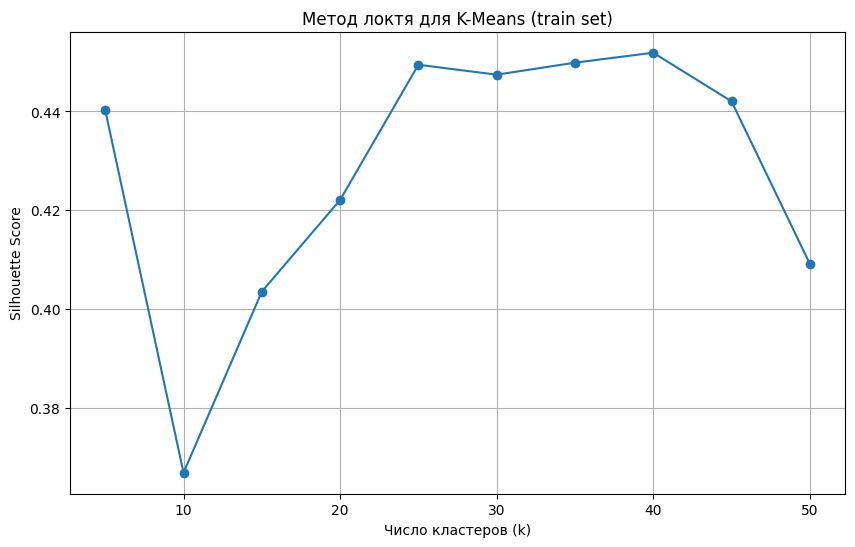

Наибольший силуэт-скор 0.4519 достигнут в случае 40 кластеров


In [42]:
silhouette_scores = []
n_clusters_range = range(5, 51, 5)

for n_clusters in n_clusters_range:
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    kmeans.fit(X_train_ll)

    val_clusters = kmeans.predict(X_val_ll)
    if len(np.unique(val_clusters)) < 2:
        score = -1.0 # если только 1 кластер в валид данных
    else:
        score = silhouette_score(X_val_ll, val_clusters, random_state=42)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(n_clusters_range, silhouette_scores, marker='o')
plt.title('Метод локтя для K-Means (train set)')
plt.xlabel('Число кластеров (k)')
plt.ylabel('Silhouette Score')
#plt.xticks(n_clusters_range[::4])
plt.grid(True)
plt.show()

best_n_clusters = n_clusters_range[np.argmax(silhouette_scores)]
max_silhouette_score = np.max(silhouette_scores)

print(f"Наибольший силуэт-скор {max_silhouette_score:.4f} достигнут в случае {best_n_clusters} кластеров")

- Из графика видно, что 25 кластеров в целом достаточно - можем проверить кач-во кластеризации методами уменьшения размерности.

In [43]:
from sklearn.manifold import TSNE

kmeans_model_25 = KMeans(n_clusters=27, init="k-means++", random_state=42)
kmeans_model_40 = KMeans(n_clusters=40, init="k-means++", random_state=42)

In [44]:
def tsne_vis(kmeans_model, X_ll):
  tsne = TSNE(n_components=2, random_state=42)
  X_tsne = tsne.fit_transform(X_ll)
  labels = kmeans_model.fit_predict(X_ll)
  plt.figure(figsize=(10,6))
  sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels, palette='tab10')
  plt.title('t-SNE visualization of k-means clusters')
  plt.xlim([-50, 50])
  plt.ylim([-50, 50])
  plt.show()

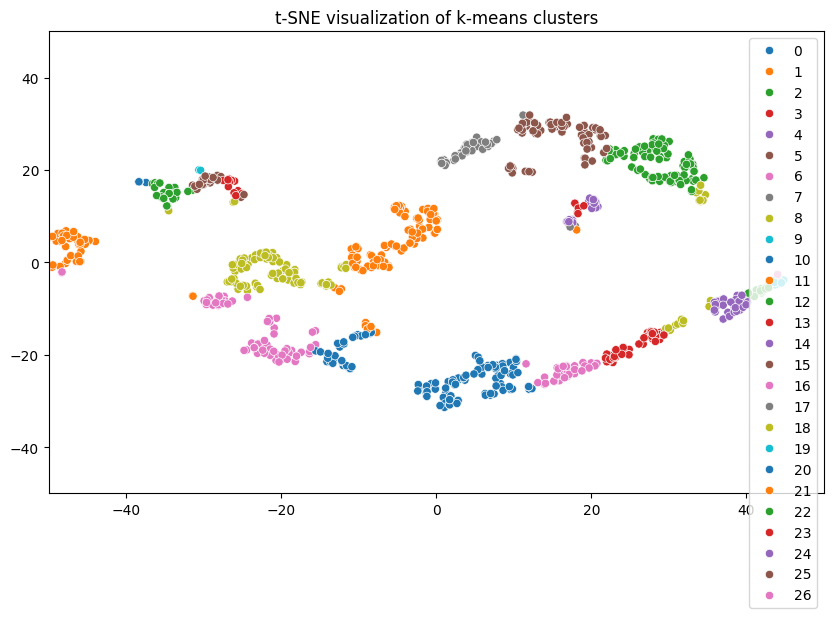

In [45]:
tsne_vis(kmeans_model_25, X_train_ll[:1000])

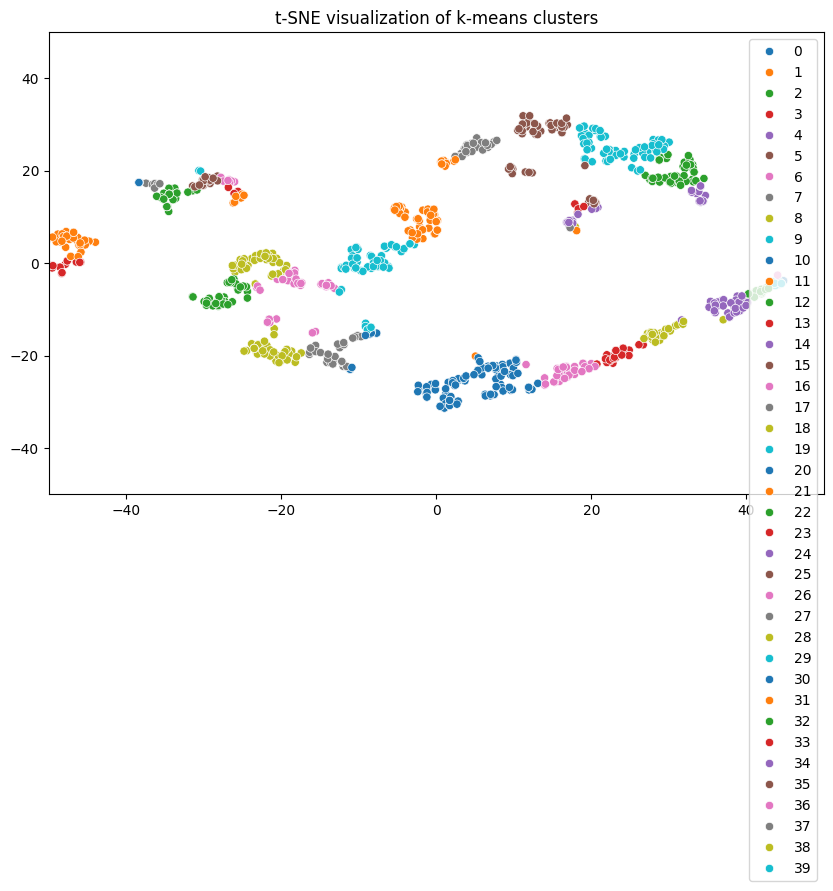

In [46]:
tsne_vis(kmeans_model_40, X_train_ll[:1000])

In [47]:
# с k=25 при проецировании на плоскость разбиение данных уже выглядит осмысленно
best_kmeans_model = KMeans(n_clusters=25, init="k-means++", random_state=42)
X_train["cluster_label"] = kmeans_model.predict(X_train_ll)
X_val["cluster_label"] = kmeans_model.predict(X_val_ll)

In [48]:
# lat, long пока оставим
X_train = delete_cols(X_train, ["features"])
X_val = delete_cols(X_val, ["features"])

In [49]:
X_train[:3]

,bathrooms,bedrooms,latitude,longitude,interest_level,bathrooms_bedrooms,bathrooms_more_2,bedrooms_more_2,dist_log,elevator,...,roofdeck,outdoorspace,diningroom,highspeedinternet,balcony,swimmingpool,newconstruction,terrace,exclusive,cluster_label
10525,1,1,40.7619,-73.9854,0,1,0,0,0.051877,0,...,0,0,0,0,0,0,0,0,0,17
39089,1,0,40.7382,-73.9965,0,0,0,0,0.026757,1,...,0,0,0,0,0,0,0,0,0,25
37274,1,2,40.6908,-73.9192,0,2,0,1,0.085760,0,...,0,0,0,0,0,0,0,0,1,13


# 7. Training

In [50]:
# трансформация таргета - qt - на практике оказалась менее оптимальна, чем обычное лог-преобразование
#qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal', random_state=42)
#
#Y_train_tr = np.array(Y_train.copy()).reshape(-1,1)
#Y_train_tr = qt.fit_transform(Y_train_tr).ravel()
#
#Y_val_tr = np.array(Y_val.copy()).reshape(-1,1)
#Y_val_tr = qt.transform(Y_val_tr).ravel()
#
#sns.histplot(data=Y_train_tr, kde=True)

(38674,)

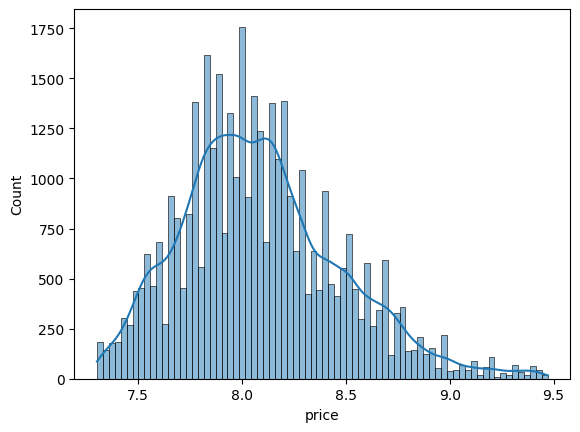

In [51]:
# трансформация таргета - log
Y_train_log = np.log1p(Y_train)
Y_val_log = np.log1p(Y_val)
sns.histplot(data=Y_train_log, kde=True)
Y_train_log.shape

In [52]:
X_train.columns

Index(['bathrooms', 'bedrooms', 'latitude', 'longitude', 'interest_level',
       'bathrooms_bedrooms', 'bathrooms_more_2', 'bedrooms_more_2', 'dist_log',
       'elevator', 'hardwoodfloors', 'catsallowed', 'dogsallowed', 'doorman',
       'dishwasher', 'laundryinbuilding', 'nofee', 'fitnesscenter',
       'laundryinunit', 'pre-war', 'roofdeck', 'outdoorspace', 'diningroom',
       'highspeedinternet', 'balcony', 'swimmingpool', 'newconstruction',
       'terrace', 'exclusive', 'cluster_label'],
      dtype='object')

In [53]:
feat_list_exp = ['bathrooms', 'bedrooms', 'latitude', 'longitude', 'interest_level',
       'bathrooms_bedrooms', 'bathrooms_more_2', 'bedrooms_more_2', 'dist_log',
       'elevator', 'hardwoodfloors', 'catsallowed', 'dogsallowed', 'doorman',
       'dishwasher', 'laundryinbuilding', 'nofee', 'fitnesscenter',
       'laundryinunit', 'pre-war', 'roofdeck', 'outdoorspace', 'diningroom',
       'highspeedinternet', 'balcony', 'swimmingpool', 'newconstruction',
       'terrace', 'exclusive', 'cluster_label']

assert feat_list_exp == list(X_train.columns), "Wrong"
assert feat_list_exp == list(X_val.columns), "Wrong"
print("Все assert-ы пройдены")

Все assert-ы пройдены


In [54]:
X_train.shape, X_val.shape

((38674, 30), (9669, 30))

In [55]:
# датафрейм для хранения результатов
dtypes = {'model': 'object', 'train': 'float64', 'valid': 'float64'}
result_MAE = pd.DataFrame(columns=['model', 'train', 'valid']).astype(dtypes)
result_MSE = pd.DataFrame(columns=['model', 'train', 'valid']).astype(dtypes)

### Отбор потенциально важных фич (кэтбуст)

In [56]:
num_cols = ["bathrooms", "bedrooms", "latitude", "longitude", "dist_log", "bathrooms_bedrooms"]
cat_cols = [col for col in X_train.columns if col not in num_cols]

In [57]:
!pip install -q catboost
from catboost import CatBoostRegressor

In [58]:
cb = CatBoostRegressor(
    iterations=1000,               # Количество деревьев
    learning_rate=0.03,            # Скорость обучения (чем ниже, тем лучше, но нужна компенсация iterations)
    depth=6,                       # Глубина дерева
    l2_leaf_reg=3,                 # L2-регуляризация для борьбы с переобучением
    loss_function='RMSE',          # Функция потерь для обучения
    eval_metric='MAE',             # Метрика для отслеживания на валидации
    cat_features=cat_cols,
    random_seed=42,
    verbose=100,                  # Печатать результат каждые 100 итераций
    early_stopping_rounds=100     # Остановиться, если метрика на валидации не улучшается
)

cb.fit(
    X_train, Y_train_log,
    eval_set=(X_val, Y_val_log),
    use_best_model=True,
    verbose=100
)

0:	learn: 0.2972811	test: 0.2946859	best: 0.2946859 (0)	total: 76.1ms	remaining: 1m 15s
100:	learn: 0.1357841	test: 0.1333986	best: 0.1333986 (100)	total: 8.09s	remaining: 1m 11s
200:	learn: 0.1222901	test: 0.1203522	best: 0.1203522 (200)	total: 22.1s	remaining: 1m 27s
300:	learn: 0.1170418	test: 0.1155878	best: 0.1155878 (300)	total: 28.3s	remaining: 1m 5s
400:	learn: 0.1133697	test: 0.1123828	best: 0.1123828 (400)	total: 35.9s	remaining: 53.7s
500:	learn: 0.1107257	test: 0.1102329	best: 0.1102329 (500)	total: 48.8s	remaining: 48.6s
600:	learn: 0.1085724	test: 0.1085365	best: 0.1085365 (600)	total: 57s	remaining: 37.8s
700:	learn: 0.1068627	test: 0.1072093	best: 0.1072093 (700)	total: 1m 2s	remaining: 26.6s
800:	learn: 0.1054107	test: 0.1061342	best: 0.1061342 (800)	total: 1m 5s	remaining: 16.2s
900:	learn: 0.1041369	test: 0.1051771	best: 0.1051771 (900)	total: 1m 11s	remaining: 7.82s
999:	learn: 0.1029323	test: 0.1043028	best: 0.1043028 (999)	total: 1m 17s	remaining: 0us

bestTest = 

CatBoostRegressor(cat_features=['interest_level', 'bathrooms_more_2', 'bedrooms_more_2', 'elevator', 'hardwoodfloors', 'catsallowed', 'dogsallowed', 'doorman', 'dishwasher', 'laundryinbuilding', 'nofee', 'fitnesscenter', 'laundryinunit', 'pre-war', 'roofdeck', 'outdoorspace', 'diningroom', 'highspeedinternet', 'balcony', 'swimmingpool', 'newconstruction', 'terrace', 'exclusive', 'cluster_label'], depth=6, early_stopping_rounds=100, eval_metric='MAE', iterations=1000, l2_leaf_reg=3, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [59]:
train_pred = cb.predict(X_train)
val_pred = cb.predict(X_val)

train_pred_orig  = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [60]:
new_mae = pd.DataFrame({
    'model': ['catboost_regression_baseline'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['catboost_regression_baseline'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [61]:
feature_importance = cb.get_feature_importance()
fi_df = pd.DataFrame({'feature': X_train.columns, 'importance': feature_importance})
fi_df.sort_values('importance', ascending=False).head(20)

,feature,importance
5,bathrooms_bedrooms,19.877965
3,longitude,13.651906
8,dist_log,12.077904
1,bedrooms,10.723048
2,latitude,8.645273
13,doorman,6.616752
4,interest_level,5.890628
0,bathrooms,4.653425
6,bathrooms_more_2,3.578373
7,bedrooms_more_2,3.295211


In [62]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.738969,393.529445


In [63]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.517968,638.487406


- В целом по метрикам базовый catboost уже дает хороший результат (ошибка порядка 390$ при разбросе цены от 1000 до 120000), но попробуем использовать результат - коэффициенты важности фич - чтобы приблизиться к похожему качеству для других моделей.

### Linear Regression

In [64]:
X_train.columns

Index(['bathrooms', 'bedrooms', 'latitude', 'longitude', 'interest_level',
       'bathrooms_bedrooms', 'bathrooms_more_2', 'bedrooms_more_2', 'dist_log',
       'elevator', 'hardwoodfloors', 'catsallowed', 'dogsallowed', 'doorman',
       'dishwasher', 'laundryinbuilding', 'nofee', 'fitnesscenter',
       'laundryinunit', 'pre-war', 'roofdeck', 'outdoorspace', 'diningroom',
       'highspeedinternet', 'balcony', 'swimmingpool', 'newconstruction',
       'terrace', 'exclusive', 'cluster_label'],
      dtype='object')

- Наиболее оптимальным для линейной регрессии оказался следующий пайплайн:
- полиномиальные фичи от логарифма расстояния, кол-ва ванн и спален;
- обработка "interest_level", "cluster_label" как категориальных фич через OHE;
- отобранные на кэтбусте по важности признаки из топ20: "doorman", "fitnesscenter", "elevator", "laundryinunit" (они уже энкодированы как 0/1 после препроцессинга).

In [65]:
center = (40.7128, -74.0060)
X_train['dist'] = np.log(((X_train['latitude']-center[0])**2 + (X_train['longitude']-center[1])**2)**0.5 + 1)
X_val['dist'] = np.log(((X_val['latitude']-center[0])**2 + (X_val['longitude']-center[1])**2)**0.5 + 1)

In [66]:
X_train_new = X_train[["bathrooms", "bedrooms", "latitude", "longitude", "dist","doorman", "interest_level","cluster_label", "fitnesscenter", "elevator", "laundryinunit"]].copy()
X_val_new = X_val[["bathrooms", "bedrooms", "latitude", "longitude", "dist", "doorman", "interest_level","cluster_label", "fitnesscenter", "elevator", "laundryinunit"]].copy()

In [67]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


preprocessor = ColumnTransformer([
    ('poly', PolynomialFeatures(2), ["bathrooms", "bedrooms", 'dist']),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), ["interest_level", "cluster_label"]),
    ('other', 'passthrough', ["doorman", "latitude", "longitude", "fitnesscenter", "elevator", "laundryinunit"])
])

In [68]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

In [69]:
# логарифмируем таргет
Y_train_log = np.log1p(Y_train)
Y_val_log = np.log1p(Y_val)

In [70]:
pipeline.fit(X_train_new, Y_train_log)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('poly', PolynomialFeatures(),
                                                  ['bathrooms', 'bedrooms',
                                                   'dist']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['interest_level',
                                                   'cluster_label']),
                                                 ('other', 'passthrough',
                                                  ['doorman', 'latitude',
                                                   'longitude', 'fitnesscenter',
                                                   'elevator',
                                                   'laundryinunit'])])),
                ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [71]:
train_pred = pipeline.predict(X_train_new)
val_pred = pipeline.predict(X_val_new)

# возвращаем таргет к первоначальному масштабу
train_pred_orig  = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [72]:
new_mae = pd.DataFrame({
    'model': ['linear_regression'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['linear_regression'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [73]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.738969,393.529445
1,linear_regression,541.360792,531.090931


In [74]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.517968,638.487406
1,linear_regression,868.826479,833.725031


### CatboostRegressor

- попробуем кэтбуст c отобранными фичами, как категориальные фичи передаем те же "interest_level", "cluster_label"; остальные считаются числовыми

In [75]:
cat_cols = ["interest_level", "cluster_label"]

In [76]:
cb = CatBoostRegressor(
    iterations=1000,               # Количество деревьев
    learning_rate=0.03,            # Скорость обучения (чем ниже, тем лучше, но нужна компенсация iterations)
    depth=6,                       # Глубина дерева
    l2_leaf_reg=3,                 # L2-регуляризация для борьбы с переобучением
    loss_function='RMSE',          # Функция потерь для обучения
    eval_metric='MAE',             # Метрика для отслеживания на валидации
    cat_features=cat_cols,
    random_seed=42,
    verbose=100,                  # Печатать результат каждые 100 итераций
    early_stopping_rounds=100     # Остановиться, если метрика на валидации не улучшается
)

cb.fit(
    X_train_new, Y_train_log,
    eval_set=(X_val_new, Y_val_log),
    use_best_model=True,
    verbose=100
)

0:	learn: 0.2973665	test: 0.2948015	best: 0.2948015 (0)	total: 108ms	remaining: 1m 48s
100:	learn: 0.1367662	test: 0.1343333	best: 0.1343333 (100)	total: 8.21s	remaining: 1m 13s
200:	learn: 0.1250033	test: 0.1229860	best: 0.1229860 (200)	total: 13.8s	remaining: 54.7s
300:	learn: 0.1203477	test: 0.1187159	best: 0.1187159 (300)	total: 23.9s	remaining: 55.6s
400:	learn: 0.1174335	test: 0.1161817	best: 0.1161817 (400)	total: 36.4s	remaining: 54.3s
500:	learn: 0.1150937	test: 0.1141809	best: 0.1141809 (500)	total: 41.7s	remaining: 41.6s
600:	learn: 0.1132746	test: 0.1127699	best: 0.1127699 (600)	total: 47.3s	remaining: 31.4s
700:	learn: 0.1116156	test: 0.1113808	best: 0.1113808 (700)	total: 58.8s	remaining: 25.1s
800:	learn: 0.1101743	test: 0.1102275	best: 0.1102275 (800)	total: 1m 5s	remaining: 16.3s
900:	learn: 0.1090058	test: 0.1093255	best: 0.1093255 (900)	total: 1m 8s	remaining: 7.48s
999:	learn: 0.1079897	test: 0.1085537	best: 0.1085537 (999)	total: 1m 10s	remaining: 0us

bestTest = 0

CatBoostRegressor(cat_features=['interest_level', 'cluster_label'], depth=6, early_stopping_rounds=100, eval_metric='MAE', iterations=1000, l2_leaf_reg=3, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [77]:
train_pred = cb.predict(X_train_new)
val_pred = cb.predict(X_val_new)


train_pred_orig  = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [78]:
new_mae = pd.DataFrame({
    'model': ['catboost_regression_fe'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['catboost_regression_fe'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [79]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.738969,393.529445
1,linear_regression,541.360792,531.090931
2,catboost_regression_fe,407.644599,407.770800


In [80]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.517968,638.487406
1,linear_regression,868.826479,833.725031
2,catboost_regression_fe,666.759059,657.646105


###

### Decision Tree

In [81]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train_new, Y_train_log)

DecisionTreeRegressor(random_state=42)

In [82]:
train_pred = tree_model.predict(X_train_new)
val_pred = tree_model.predict(X_val_new)

train_pred_orig = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [83]:
new_mae = pd.DataFrame({
    'model': ['tree_regression'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['tree_regression'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [84]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.738969,393.529445
1,linear_regression,541.360792,531.090931
2,catboost_regression_fe,407.644599,407.770800
3,tree_regression,83.615161,341.939083


In [85]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.517968,638.487406
1,linear_regression,868.826479,833.725031
2,catboost_regression_fe,666.759059,657.646105
3,tree_regression,214.847480,678.086331


- Одиночное дерево сильно переобучилось, что видно по резкому увеличению обех метрик на валидационных данных.

### Forest

In [86]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train_new, Y_train_log)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [87]:
train_pred = rf.predict(X_train_new)
val_pred = rf.predict(X_val_new)

train_pred_orig = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [88]:
new_mae = pd.DataFrame({
    'model': ['forest_regression'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['forest_regression'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [89]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.738969,393.529445
1,linear_regression,541.360792,531.090931
2,catboost_regression_fe,407.644599,407.770800
3,tree_regression,83.615161,341.939083
4,forest_regression,158.925796,302.124019


In [90]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.517968,638.487406
1,linear_regression,868.826479,833.725031
2,catboost_regression_fe,666.759059,657.646105
3,tree_regression,214.847480,678.086331
4,forest_regression,299.269074,546.869962


 Лес тоже переобучен, подберем параметры регуляризации:

In [91]:
rf = RandomForestRegressor(
    n_estimators=100,        # меньше
    max_depth=10,
    min_samples_split=20,    # сильнее
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_new, Y_train_log)

RandomForestRegressor(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                      n_jobs=-1, random_state=42)

In [92]:
train_pred = rf.predict(X_train_new)
val_pred = rf.predict(X_val_new)

train_pred_orig = np.expm1(train_pred)
val_pred_orig = np.expm1(val_pred)

train_mae = mean_absolute_error(Y_train, train_pred_orig)
valid_mae = mean_absolute_error(Y_val, val_pred_orig)

train_rmse = np.sqrt(mean_squared_error(Y_train, train_pred_orig))
valid_rmse = np.sqrt(mean_squared_error(Y_val, val_pred_orig))

In [93]:
new_mae = pd.DataFrame({
    'model': ['forest_regression_reg'],
    'train': [train_mae],
    'valid': [valid_mae]
})

new_rmse = pd.DataFrame({
    'model': ['forest_regression_reg'],
    'train': [train_rmse],
    'valid': [valid_rmse]
})

result_MAE = pd.concat([result_MAE, new_mae], ignore_index=True)
result_MSE = pd.concat([result_MSE, new_rmse], ignore_index=True)

In [94]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.738969,393.529445
1,linear_regression,541.360792,531.090931
2,catboost_regression_fe,407.644599,407.770800
3,tree_regression,83.615161,341.939083
4,forest_regression,158.925796,302.124019
5,forest_regression_reg,445.236227,445.154586


In [95]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.517968,638.487406
1,linear_regression,868.826479,833.725031
2,catboost_regression_fe,666.759059,657.646105
3,tree_regression,214.847480,678.086331
4,forest_regression,299.269074,546.869962
5,forest_regression_reg,746.471370,720.936274


Лучше, чем линрег, но хуже, чем базовый кэтбуст. Параметры регуляризации можно в дальнейшем подобрать randomized search.

### Сравнение с "наивными" моделями

In [96]:
train_price_mean = np.mean(Y_train)
train_price_median = np.median(Y_train)

val_price_mean = np.mean(Y_val)
val_price_median  = np.median(Y_val)

In [97]:
## MAE on training between target and mean or median AND on test between target and mean or median
train_mean_mae = mean_absolute_error(Y_train, np.full_like(Y_train, train_price_mean))
train_median_mae = mean_absolute_error(Y_train, np.full_like(Y_train, train_price_median))
val_mean_mae = mean_absolute_error(Y_val, np.full_like(Y_val, val_price_mean))
val_median_mae = mean_absolute_error(Y_val, np.full_like(Y_val, val_price_median))

In [98]:
## RMSE on training between target and mean or median AND on test between target and mean or median
train_mean_mse = np.sqrt(mean_squared_error(Y_train, np.full_like(Y_train, train_price_mean)))
train_median_mse = np.sqrt(mean_squared_error(Y_train, np.full_like(Y_train, train_price_median)))
val_mean_mse = np.sqrt(mean_squared_error(Y_val, np.full_like(Y_val, val_price_mean)))
val_median_mse = np.sqrt(mean_squared_error(Y_val, np.full_like(Y_val, val_price_median)))

In [99]:
result_MAE = pd.concat([
    result_MAE,
    pd.DataFrame({
        'model': ['naive_mean', 'naive_median'],
        'train': [train_mean_mae, train_median_mae],
        'valid': [val_mean_mae, val_median_mae]
    })
], ignore_index=True)

In [100]:
result_MSE = pd.concat([
    result_MSE,
    pd.DataFrame({
        'model': ['naive_mean', 'naive_median'],
        'train': [train_mean_mse, train_median_mse],
        'valid': [val_mean_mse, val_median_mse]
    })
], ignore_index=True)

### Выбор лучшей модели

- Print your final result_MAE and result_RMSE tables.
- Which is the best model?

In [101]:
result_MAE

,model,train,valid
0,catboost_regression_baseline,389.738969,393.529445
1,linear_regression,541.360792,531.090931
2,catboost_regression_fe,407.644599,407.770800
3,tree_regression,83.615161,341.939083
4,forest_regression,158.925796,302.124019
5,forest_regression_reg,445.236227,445.154586
6,naive_mean,1137.014040,1122.444410
7,naive_median,1084.733335,1072.171476


In [102]:
result_MSE

,model,train,valid
0,catboost_regression_baseline,642.517968,638.487406
1,linear_regression,868.826479,833.725031
2,catboost_regression_fe,666.759059,657.646105
3,tree_regression,214.847480,678.086331
4,forest_regression,299.269074,546.869962
5,forest_regression_reg,746.471370,720.936274
6,naive_mean,1591.214781,1562.966777
7,naive_median,1637.597067,1607.997940


- Лучшая модель - catboost на топ-20 отобранных признаков из колонки features и некоторых модификациях bathrooms, bedrooms. Показал хорошие метрики (mae 390 и 394, rmse 643 и 639 на тренировочной и валидационной выборках соответственно) и отсутствие переобучения.
- Еще потенциально хорошая модель - случайный лес, модель с дефолтными параметрами показала переобучение, однако после ручной регуляризации переобучение исчезло (можно подобрать гиперпараметры).
- Все модели показали себя лучше "наивных" (которые предсказывали бы чисто среднее или медиану для всех точек данных).

### Попытки оптимизировать гиперпараметры catboost с помощью optuna и randomized search

In [ ]:
/////

In [ ]:
!pip install -q optuna
import optuna

In [ ]:
def objective(trial):
  cat_cols = ["interest_level", "cluster_label"]
  params = {
        'iterations': trial.suggest_categorical('iterations', [1000, 1500]),
        'learning_rate': trial.suggest_categorical('learning_rate', [0.02, 0.03, 0.05]),
        'depth': trial.suggest_categorical('depth', [6, 8, 10]),
        'l2_leaf_reg': trial.suggest_categorical('l2_leaf_reg', [3, 5, 7]),
        'random_seed': 42,
        'verbose': 0,
        'cat_features': cat_cols
    }



  model = CatBoostRegressor(**params)
  model.fit(
      X_train_new, Y_train_log,
      eval_set=(X_val_new, Y_val_log),
      early_stopping_rounds=50,
      verbose=False
  )


  Y_pred_log = model.predict(X_val_new)
  Y_pred = np.expm1(Y_pred_log)
  mae = mean_absolute_error(Y_val, Y_pred)
  return mae

In [ ]:
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print(f"\nBest MAE: {study.best_value:.2f}")
print(f"Best hyperparameters: {best_params}")

In [ ]:
from sklearn.model_selection import RandomizedSearchCV


cb = CatBoostRegressor(random_seed=42, verbose=0)


param_grid = {
    'iterations': [1000, 1500, 2000],
    'learning_rate': [0.01, 0.02, 0.03, 0.05],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 10],
    'bagging_temperature': [0.5, 0.8, 1.0],
    'random_strength': [0.5, 1, 2]
}


random_search = RandomizedSearchCV(
    cb,
    param_grid,
    n_iter=30,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)


cat_features = ['interest_level', 'cluster_label']


random_search.fit(
    X_train_new, Y_train_log,
    cat_features=cat_features,
    eval_set=(X_val_new, Y_val_log),
    early_stopping_rounds=50,
    verbose=False
)